# Part 2: Post-Training Quantization (PTQ)

## 이 노트북에서 다루는 내용
1. Dynamic Quantization (동적 양자화)
2. Static Quantization (정적 양자화)
3. PTQ 결과 비교 (정확도, 모델 크기, 추론 시간)
4. 양자화된 가중치 분포 시각화

## PTQ 핵심 개념

### Dynamic Quantization
- 가중치: 사전에 INT8로 변환
- 활성화: 추론 시 실시간으로 양자화
- calibration 불필요, 적용 간단
- Conv2d에는 지원 제한적 → Linear만 적용

### Static Quantization
- 가중치 + 활성화 모두 사전에 INT8로 변환
- calibration 데이터로 활성화 범위 미리 측정
- 모델 구조: QuantStub → 연산 → DeQuantStub
- Conv+ReLU, Linear+ReLU 융합으로 추가 성능 향상

## [1] 환경 설정 및 데이터 로드

In [1]:
import os
import copy
import time
import tempfile

import torch
import torch.nn as nn
import torch.optim as optim
import torch.ao.quantization as quant
import torchvision.transforms as transforms
import torchvision.datasets as datasets
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

from module.models import CNN, QuantizableCNN

def get_device():
    if torch.cuda.is_available():
        return "cuda"
    elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
        return "mps"
    return "cpu"

DEVICE = get_device()
BATCH_SIZE = 128
EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10
SEED = 42
torch.manual_seed(SEED)
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_dataset = datasets.CIFAR10(root='./data/datasets', train=True, download=True, transform=transform)
test_dataset = datasets.CIFAR10(root='./data/datasets', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"학습: {len(train_dataset):,}, 테스트: {len(test_dataset):,}")

학습: 50,000, 테스트: 10,000


## [2] 유틸리티 함수

In [5]:
def train_model(model, train_loader, epochs, learning_rate, device):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    model.to(device)
    model.train()

    for epoch in range(epochs):
        running_loss = 0.0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")


def test_model(model, test_loader, device):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100 * correct / total


def get_model_size_mb(model):
    tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.pth')
    tmp_path = tmp.name
    tmp.close()
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    return size_mb


def measure_inference_time(model, test_loader, device, num_batches=50):
    model.to(device)
    model.eval()
    # Warmup
    with torch.no_grad():
        for i, (inputs, _) in enumerate(test_loader):
            if i >= 5: break
            _ = model(inputs.to(device))
    # 측정
    start = time.time()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(test_loader):
            if i >= num_batches: break
            _ = model(inputs.to(device))
    return time.time() - start

## [3] Baseline 모델 준비

In [4]:
torch.manual_seed(SEED)
model = CNN(num_classes=NUM_CLASSES)

# 학습
train_model(model, train_loader, EPOCHS, LEARNING_RATE, DEVICE)

model.to(DEVICE)
baseline_acc = test_model(model, test_loader, DEVICE)
baseline_size = get_model_size_mb(model)
print(f"\nBaseline 정확도: {baseline_acc:.2f}%")
print(f"Baseline 크기: {baseline_size:.2f} MB")

fp32_state_dict = copy.deepcopy(model.cpu().state_dict())

Epoch 1/10, Loss: 1.3422
Epoch 2/10, Loss: 0.8709
Epoch 3/10, Loss: 0.6855
Epoch 4/10, Loss: 0.5462
Epoch 5/10, Loss: 0.4350
Epoch 6/10, Loss: 0.3331
Epoch 7/10, Loss: 0.2431
Epoch 8/10, Loss: 0.1872
Epoch 9/10, Loss: 0.1485
Epoch 10/10, Loss: 0.1347

Baseline 정확도: 75.01%
Baseline 크기: 4.53 MB


## [4] Dynamic Quantization

가장 간단한 양자화 방법. `quantize_dynamic()`으로 한 줄로 적용.
Linear 레이어만 INT8로 변환합니다.

In [6]:
# Dynamic Quantization 적용
model_cpu = copy.deepcopy(model).cpu()
model_cpu.eval()

dynamic_model = quant.quantize_dynamic(
    model_cpu,
    {nn.Linear},  # Linear 레이어만 양자화
    dtype=torch.qint8
)

# 결과 확인
dynamic_acc = test_model(dynamic_model, test_loader, 'cpu')
dynamic_size = get_model_size_mb(dynamic_model)

print(f"\nDynamic PTQ 정확도: {dynamic_acc:.2f}%")
print(f"Dynamic PTQ 크기: {dynamic_size:.2f} MB")
print(f"크기 감소율: {(1 - dynamic_size / baseline_size) * 100:.1f}%")
print(f"\n참고: Conv2d는 양자화되지 않아 크기 감소가 제한적입니다.")


Dynamic PTQ 정확도: 75.04%
Dynamic PTQ 크기: 1.52 MB
크기 감소율: 66.5%

참고: Conv2d는 양자화되지 않아 크기 감소가 제한적입니다.


## [5] Static Quantization

QuantizableCNN(QuantStub/DeQuantStub 포함) + fuse_model + calibration → 전체 양자화

In [7]:
def load_cnn_weights_to_quantizable(fp32_state_dict, num_classes=10):
    """CNN → QuantizableCNN 가중치 매핑"""
    qmodel = QuantizableCNN(num_classes=num_classes)
    quant_sd = {}
    for key, value in fp32_state_dict.items():
        if key.startswith('features.'):
            quant_sd[key] = value
        elif key == 'classifier.0.weight':
            quant_sd['classifier.0.weight'] = value
        elif key == 'classifier.0.bias':
            quant_sd['classifier.0.bias'] = value
        elif key == 'classifier.3.weight':
            quant_sd['classifier.2.weight'] = value
        elif key == 'classifier.3.bias':
            quant_sd['classifier.2.bias'] = value
    qmodel.load_state_dict(quant_sd)
    return qmodel

In [8]:
# Static Quantization 적용
static_model = load_cnn_weights_to_quantizable(fp32_state_dict, NUM_CLASSES)

# 1. eval 모드 → fuse_model
static_model.eval()
static_model.fuse_model()
print("레이어 융합 완료 (Conv+ReLU, Linear+ReLU)")

# 2. qconfig 설정 (fbgemm = x86 CPU 최적화)
static_model.qconfig = quant.get_default_qconfig('fbgemm')

# 3. prepare: observer 삽입
quant.prepare(static_model, inplace=True)
print("Observer 삽입 완료")

# 4. Calibration: 학습 데이터 통과
NUM_CALIBRATION_BATCHES = 100
print(f"Calibration 진행 중 ({NUM_CALIBRATION_BATCHES} batches)...")
with torch.no_grad():
    for i, (inputs, _) in enumerate(train_loader):
        if i >= NUM_CALIBRATION_BATCHES:
            break
        static_model(inputs)

# 5. Convert: 실제 양자화
quant.convert(static_model, inplace=True)
print("양자화 변환 완료!")

# 결과 확인
static_acc = test_model(static_model, test_loader, 'cpu')
static_size = get_model_size_mb(static_model)

print(f"\nStatic PTQ 정확도: {static_acc:.2f}%")
print(f"Static PTQ 크기: {static_size:.2f} MB")
print(f"크기 감소율: {(1 - static_size / baseline_size) * 100:.1f}%")

레이어 융합 완료 (Conv+ReLU, Linear+ReLU)
Observer 삽입 완료
Calibration 진행 중 (100 batches)...


c:\Users\jskim\anaconda3\envs\distillation\lib\site-packages\torch\ao\quantization\observer.py:244: UserWarning: Please use quant_min and quant_max to specify the range for observers.                     reduce_range will be deprecated in a future release of PyTorch.
  warnings.warn(


양자화 변환 완료!

Static PTQ 정확도: 74.84%
Static PTQ 크기: 1.16 MB
크기 감소율: 74.4%


## [6] 추론 시간 비교 (CPU)

In [9]:
# 모든 모델 CPU에서 비교 (양자화 모델은 CPU 전용)
model_cpu = copy.deepcopy(model).cpu()

baseline_time = measure_inference_time(model_cpu, test_loader, 'cpu')
dynamic_time = measure_inference_time(dynamic_model, test_loader, 'cpu')
static_time = measure_inference_time(static_model, test_loader, 'cpu')

print(f"Baseline (FP32): {baseline_time:.3f}초")
print(f"Dynamic PTQ:     {dynamic_time:.3f}초 ({dynamic_time/baseline_time*100:.1f}%)")
print(f"Static PTQ:      {static_time:.3f}초 ({static_time/baseline_time*100:.1f}%)")

Baseline (FP32): 4.342초
Dynamic PTQ:     4.295초 (98.9%)
Static PTQ:      1.646초 (37.9%)


## [7] 가중치 분포 비교 시각화

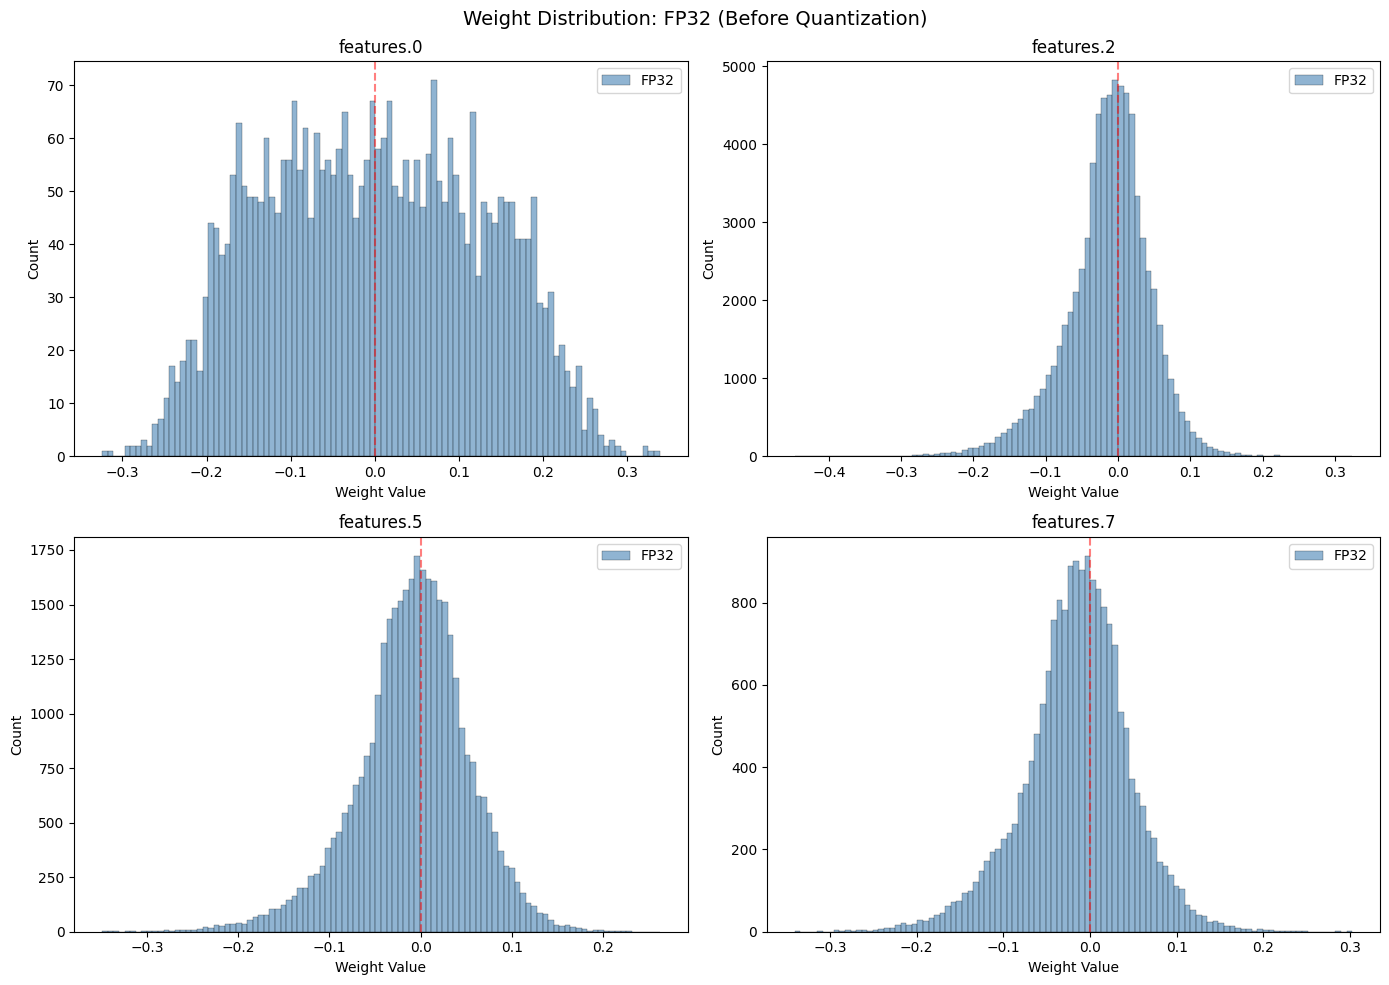

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Weight Distribution: FP32 (Before Quantization)', fontsize=14)

conv_layers = []
for name, module in model.named_modules():
    if isinstance(module, nn.Conv2d):
        conv_layers.append((name, module.weight.data.cpu().numpy().flatten()))

for idx, (name, weights) in enumerate(conv_layers[:4]):
    ax = axes[idx // 2][idx % 2]
    ax.hist(weights, bins=100, alpha=0.6, color='steelblue', label='FP32', edgecolor='black', linewidth=0.3)
    ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
    ax.set_title(f'{name}')
    ax.set_xlabel('Weight Value')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

## [8] PTQ 결과 비교

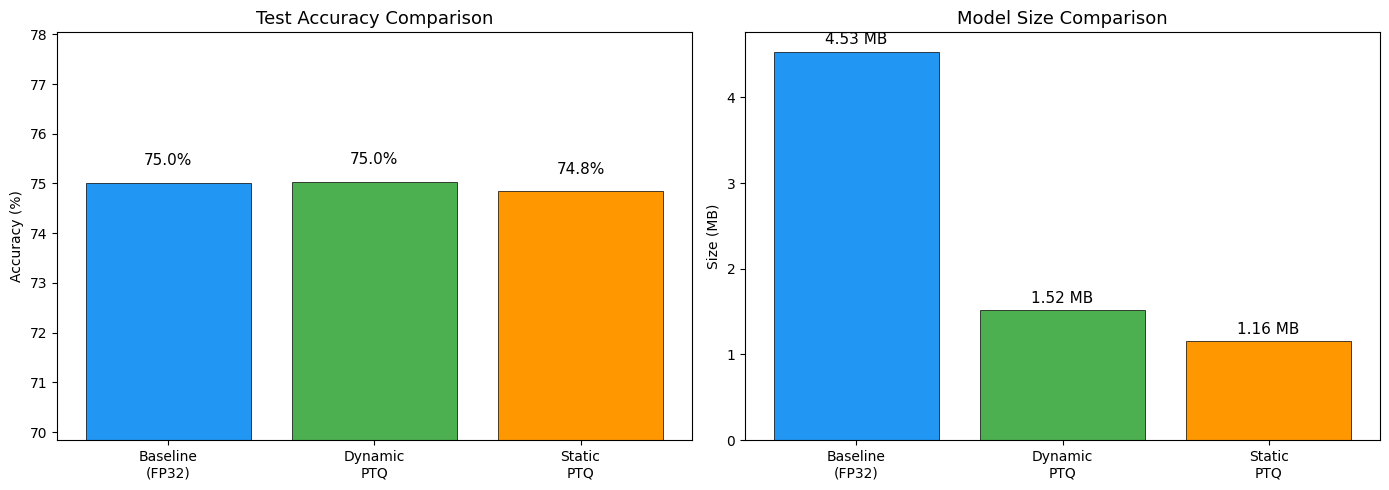

In [11]:
methods = ['Baseline\n(FP32)', 'Dynamic\nPTQ', 'Static\nPTQ']
accuracies = [baseline_acc, dynamic_acc, static_acc]
sizes = [baseline_size, dynamic_size, static_size]
colors = ['#2196F3', '#4CAF50', '#FF9800']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 정확도 비교
bars1 = ax1.bar(methods, accuracies, color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Test Accuracy Comparison', fontsize=13)
ax1.set_ylabel('Accuracy (%)')
ax1.set_ylim(min(accuracies) - 5, max(accuracies) + 3)
for bar, acc in zip(bars1, accuracies):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=11)

# 크기 비교
bars2 = ax2.bar(methods, sizes, color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title('Model Size Comparison', fontsize=13)
ax2.set_ylabel('Size (MB)')
for bar, s in zip(bars2, sizes):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{s:.2f} MB', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## 결과 요약

In [12]:
print("=" * 60)
print("PTQ 결과 요약")
print("=" * 60)
print(f"{'Method':<25} {'Accuracy':>10} {'Size (MB)':>10} {'Speed':>10}")
print("-" * 55)
print(f"{'Baseline (FP32)':<25} {baseline_acc:>9.2f}% {baseline_size:>9.2f} {baseline_time:>9.3f}s")
print(f"{'Dynamic PTQ':<25} {dynamic_acc:>9.2f}% {dynamic_size:>9.2f} {dynamic_time:>9.3f}s")
print(f"{'Static PTQ':<25} {static_acc:>9.2f}% {static_size:>9.2f} {static_time:>9.3f}s")
print(f"\nDynamic PTQ: Linear만 양자화 → 크기 감소 제한적, 적용 간단")
print(f"Static PTQ: 전체 양자화 → 크기 대폭 감소, calibration 필요")

PTQ 결과 요약
Method                      Accuracy  Size (MB)      Speed
-------------------------------------------------------
Baseline (FP32)               75.01%      4.53     4.342s
Dynamic PTQ                   75.04%      1.52     4.295s
Static PTQ                    74.84%      1.16     1.646s

Dynamic PTQ: Linear만 양자화 → 크기 감소 제한적, 적용 간단
Static PTQ: 전체 양자화 → 크기 대폭 감소, calibration 필요
